In [1]:
import numpy as np 
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
import os
import pandas as pd
from pathlib import Path
import pickle
import histlite as hl
from math import prod
import sys
sys.path.append(os.path.abspath("../../../"))
from kingmaker_fork.kingmaker.wrapper import KingSpatialLikelihood
import kingmaker_fork.likelihood_analysis.analysis_helpers.fitting_plots as fplt
from kingmaker_fork.likelihood_analysis.analysis_helpers.get_bin_egdes import get_bin_info
from kingmaker_fork.likelihood_analysis.utils.trial_runner_config_loading import restore_king_trial_runner
import csky as cy
from kingmaker_fork.likelihood_analysis.utils.parallel_king_trials import get_many_fits_from_trials


from csky_gfu_tests.custom_gfu_specs import GFUDataSpecs as custom_gfu



## Load Rayleigh Benchmark runs

In [2]:
rayleigh_benchmark_path = Path('/data/user/fkrafft/csky_gfu_tests/2023_sig_gamma_2.5_PS_energy_bins')

In [3]:
rayleigh_data_3sig_disc = {}
for file in rayleigh_benchmark_path.glob("rayleigh_3sig_disc*.json"):
    with open(file) as f:
        sens_data = json.load(f)

    # extract sin(dec) from filename
    # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
    name = file.stem

    sindec_str = name.split("sindec_")[1].split("_N_")[0]
    sin_dec = float(sindec_str)

    # store inside your existing data object
    rayleigh_data_3sig_disc[sin_dec] = sens_data    
    
rayleigh_data_sens = {}
for file in rayleigh_benchmark_path.glob("rayleigh_sens*.json"):
    with open(file) as f:
        sens_data = json.load(f)

    # extract sin(dec) from filename
    # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
    name = file.stem

    sindec_str = name.split("sindec_")[1].split("_N_")[0]
    sin_dec = float(sindec_str)

    # store inside your existing data object
    rayleigh_data_sens[sin_dec] = sens_data   

In [4]:
#load rayleigh reference:
rayleigh_data_bias = {}
for file in rayleigh_benchmark_path.glob("rayleigh_bias_small*.json"):
    name = file.stem

    sindec_str = name.split("small_")[1].split("_N_")[0]
    sin_dec = float(sindec_str)
    with open(file, "rb") as f:
        ray_allt = pickle.load(f)
    rayleigh_data_bias[sin_dec] = ray_allt    

## Load King runs

In [5]:
run_folder = Path('/data/user/fkrafft/split_sky_trials')

In [8]:
king_data_3sig_disc = {
    'north' : {},
    'south' : {}
}

king_data_sens = {
    'north' : {},
    'south' : {}
}

king_data_bias = {
        'north' : {},
        'south' : {}
}
north_folder = Path(os.path.join(run_folder, 'north'))
south_folder = Path(os.path.join(run_folder, 'south'))

for run in [p for p in north_folder.iterdir() if p.is_dir()]:
    input_dir = Path(run)
    king_data_3sig_disc['north'][run.name] = {}
    king_data_sens['north'][run.name] = {}
    king_data_bias['north'][run.name] = {}
    for file in input_dir.glob("TEST_king_3sig_disc_*.json"):

        with open(file) as f:
            sens_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_data_3sig_disc['north'][run.name][sin_dec] = sens_data 
    for file in input_dir.glob("TEST_king_sens_*.json"):

        with open(file) as f:
            sens_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_data_sens['north'][run.name][sin_dec] = sens_data 
    for file in input_dir.glob("king_bias*.json"):

        with open(file, "rb") as f:
                allt = pickle.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("SINDEC_")[1].split("_NTRIALS")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_data_bias['north'][run.name][sin_dec] = allt 
    #if no files: remove   
    if king_data_3sig_disc['north'][run.name] == {} or king_data_bias['north'][run.name] == {} or king_data_sens['north'][run.name] == {}:
        king_data_3sig_disc['north'].pop(run.name)
        king_data_sens['north'].pop(run.name)
        king_data_bias['north'].pop(run.name)
        
for run in [p for p in south_folder.iterdir() if p.is_dir()]:
    input_dir = Path(run)
    king_data_3sig_disc['south'][run.name] = {}
    king_data_sens['south'][run.name] = {}
    king_data_bias['south'][run.name] = {}
    for file in input_dir.glob("TEST_king_3sig_disc_*.json"):

        with open(file) as f:
            sens_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_data_3sig_disc['south'][run.name][sin_dec] = sens_data 
    for file in input_dir.glob("TEST_king_sens_*.json"):
        try: 
            with open(file) as f:
                sens_data = json.load(f)
        except json.JSONDecodeError:
            print("BAD FILE:", file)
            print("SIZE:", file.stat().st_size)
            break
        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_data_sens['south'][run.name][sin_dec] = sens_data 
    for file in input_dir.glob("king_bias*.json"):

        try:
            with open(file, "rb") as f:
                allt = pickle.load(f)
        except EOFError:
            print("BAD FILE:", file)
            print("SIZE:", file.stat().st_size)
            break

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("SINDEC_")[1].split("_NTRIALS")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_data_bias['south'][run.name][sin_dec] = allt 
    #if no files: remove   
    if king_data_3sig_disc['south'][run.name] == {} or king_data_bias['south'][run.name] == {} or king_data_sens['south'][run.name] == {}:
        king_data_3sig_disc['south'].pop(run.name)
        king_data_sens['south'].pop(run.name)
        king_data_bias['south'].pop(run.name)

BAD FILE: /data/user/fkrafft/split_sky_trials/south/E75_D9_fc2efc_S75_MC300/king_bias_-0.5_N_1000_SINDEC_-0.5_NTRIALS_1000_E75_D9_fc2efc_S75_MC300.json
SIZE: 0
BAD FILE: /data/user/fkrafft/split_sky_trials/south/E5_D24_b2448a_S100_MC300/TEST_king_sens_sindec_-0.5_N_1000_SINDEC_-0.5_NTRIALS_1000_E5_D24_b2448a_S100_MC300.json
SIZE: 0
BAD FILE: /data/user/fkrafft/split_sky_trials/south/E100_D9_fc2efc_S20_MC300/TEST_king_sens_sindec_-0.5_N_1000_SINDEC_-0.5_NTRIALS_1000_E100_D9_fc2efc_S20_MC300.json
SIZE: 0
BAD FILE: /data/user/fkrafft/split_sky_trials/south/E200_D44_927d0d_S75_MC300/king_bias_-0.5_N_1000_SINDEC_-0.5_NTRIALS_1000_E200_D44_927d0d_S75_MC300.json
SIZE: 0


### Correlation of bias and 3 sigma discovery potential

In [9]:
n_sigs = np.r_[:31:3]
expect_gamma = 2.5
dns = np.mean(np.diff(n_sigs))
ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]

In [10]:
def get_binning_from_path(folder_path):
    path = Path(folder_path)
    pkl_file =list( path.glob("king_trial_runner_config*.pkl"))[0]
    with open(pkl_file, "rb") as f:
        cfg = pickle.load(f)

    return cfg["parametrization_bins"]
def total_nbins(bins):
    return prod(
        value if np.ndim(value) == 0 else len(value) - 1
        for value in bins.values()
    )

def n_bins_1d(bins):
    if np.isscalar(bins) or np.ndim(bins) == 0:
        return int(bins)

    return len(bins) - 1


In [12]:
ratio_data = pd.DataFrame(columns= ['sin_dec', 'disc_flux_ratio', 'sens_flux_ratio', 'ns_bias_ratio', 'gamma_bias_ratio'])
ratio_dfs = {
    'south' : ratio_data.copy(),
    'north' : ratio_data.copy()
}
sin_decs = {
    'south' : [],
    'north' : []
}

for sky in ['north', 'south']:
    rows = []
    for run in list(king_data_3sig_disc[sky].keys()):
        sin_decs[sky] = sorted(list(king_data_3sig_disc[sky][run].keys()))
        
        for s in sin_decs[sky]:
            #disc pot ratio
            king_d_disc = king_data_3sig_disc[sky][run][s]
            rayleigh_d_disc = rayleigh_data_3sig_disc[s]
    
            flux_king_disc = king_d_disc["flux"]
            flux_ray_disc = rayleigh_d_disc['flux']
            if flux_king_disc == 'inf':
                flux_ratio_disc = 10
            else:
                flux_ratio_disc = flux_king_disc/flux_ray_disc
            
            #sens ratio
            king_d_sens = king_data_sens[sky][run][s]
            rayleigh_d_sens = rayleigh_data_sens[s]
            
            flux_king_sens = king_d_sens["flux"]
            flux_ray_sens = rayleigh_d_sens['flux']
            if flux_king_sens == 'inf':
                flux_ratio_sens = 10 # flag for failed 
            else:
                flux_ratio_sens = flux_king_sens/flux_ray_sens
            
            allt_ray = rayleigh_data_bias[s]
            allt_king = king_data_bias[sky][run][s]
            
            h_king = hl.hist(
                (allt_king["ntrue"], allt_king["ns"]),
                bins=(ns_bins, 100),
            ).contain_project(1)

            h_ray = hl.hist(
                (allt_ray["ntrue"], allt_ray["ns"]),
                bins=(ns_bins, 100),
            ).contain_project(1)
            
            x_ns = h_king.centers[0]

            # ns bias
            king_dev = h_king.values - x_ns
            ray_dev  = h_ray.values - x_ns
            ns_bias_ratio = np.mean(np.abs(king_dev))/np.mean(np.abs(ray_dev))
            
            #gamma bias
            h_king = hl.hist(
                (allt_king["ntrue"], allt_king["gamma"]),
                bins=(ns_bins, 100),
            ).contain_project(1)

            h_ray = hl.hist(
                (allt_ray["ntrue"], allt_ray["gamma"]),
                bins=(ns_bins, 100),
            ).contain_project(1)
            king_dev = h_king.values - expect_gamma
            ray_dev  = h_ray.values - expect_gamma
            gamma_bias_ratio = np.mean(np.abs(king_dev))/np.mean(np.abs(ray_dev))
            
            
            #also look into number of bins for the configurations
            parametrization_bins = get_binning_from_path(os.path.join(run_folder, sky, run))
            
            parametrization_bins = get_binning_from_path(
                os.path.join(run_folder, sky, run)
            )

            n_bins_energy = n_bins_1d(
                parametrization_bins["log10energy"]
            )
            n_bins_dec = n_bins_1d(
                parametrization_bins["dec"]
            )
            n_bins_sigma = n_bins_1d(
                parametrization_bins["sigma"]
            )

            n_bins = (
                n_bins_energy
                * n_bins_dec
                * n_bins_sigma
            )

            rows.append(
                {
                    "run": run,
                    "sin_dec": s,
                    "disc_flux_ratio": flux_ratio_disc,
                    "sens_flux_ratio": flux_ratio_sens,
                    "ns_bias_ratio": ns_bias_ratio,
                    "gamma_bias_ratio": gamma_bias_ratio,
                    "n_bins": n_bins,
                    "n_bins_energy": n_bins_energy,
                    "n_bins_dec": n_bins_dec,
                    "n_bins_sigma": n_bins_sigma,
                }
            )
                    
    ratio_dfs[sky] = pd.DataFrame.from_records(rows)

In [13]:
joined_ratio_df = df_merged = pd.concat([ratio_dfs['north'], ratio_dfs['south']], ignore_index=True)
joined_ratio_df.to_csv(os.path.join(run_folder, 'improvement_summary.csv'))

## Plot correlation of Bias and Discovery Potential Flux 

### Independent of Source Declination

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'


/tmp/ipykernel_3469577/27500117.py:7: SyntaxWarning: invalid escape sequence '\g'
  plt.scatter(ratio_dfs[sky]['gamma_bias_ratio'], ratio_dfs[sky]['flux_ratio'], alpha = 0.5, label = 'Spectral index $\gamma$')


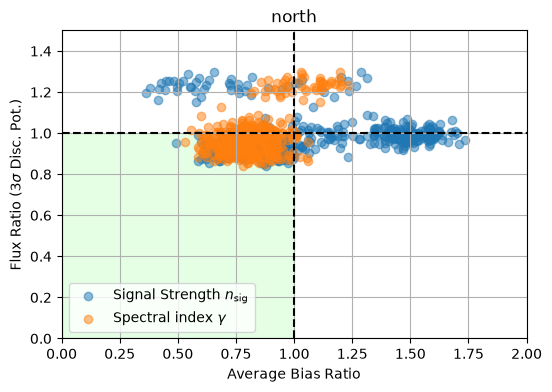

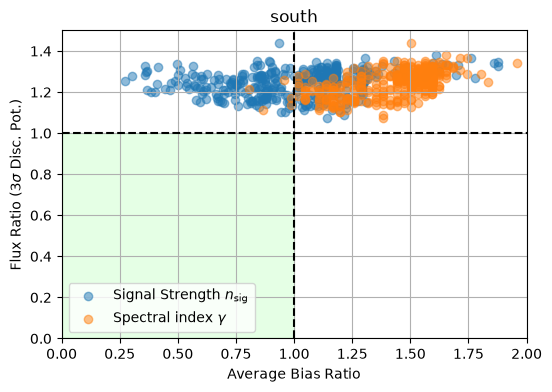

In [10]:
for sky in ['north', 'south']:
    plt.figure(figsize= (6, 4))
    plt.grid()
    plt.title(sky)
    plt.fill_between([0,1], 0, 1, color = 'lime', alpha = 0.1, zorder = 0)
    plt.scatter(ratio_dfs[sky]['ns_bias_ratio'], ratio_dfs[sky]['flux_ratio'], alpha = 0.5, label = 'Signal Strength $n_{\\text{sig}}$')
    plt.scatter(ratio_dfs[sky]['gamma_bias_ratio'], ratio_dfs[sky]['flux_ratio'], alpha = 0.5, label = 'Spectral index $\gamma$')
    plt.xlabel('Average Bias Ratio')
    plt.ylabel('Flux Ratio (3$\\sigma$ Disc. Pot.)')
    plt.axhline(1, linestyle = 'dashed', color = 'black')
    plt.axvline(1, linestyle = 'dashed', color = 'black')
    plt.xlim(0, 2)
    plt.ylim(0, 1.5)
    plt.legend()

### Dependend on source declination

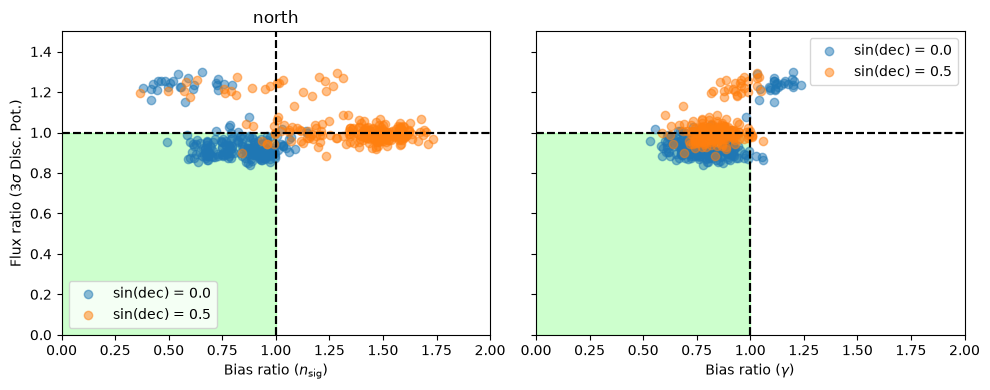

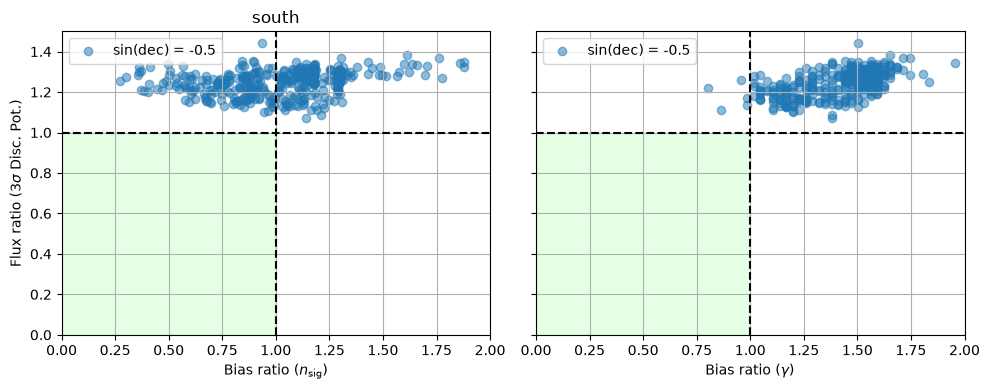

In [11]:
for sky in ['north', 'south']:
    fig, axs = plt.subplots(1,2, figsize = (10, 4), sharey = True)
    for i,sin_dec in enumerate(sin_decs[sky]):
        #n_sig plot
        sin_dec_ns_bias = ratio_dfs[sky]['ns_bias_ratio'].where(ratio_dfs[sky]['sin_dec'] == sin_dec)
        sin_dec_flux = ratio_dfs[sky]['flux_ratio'].where(ratio_dfs[sky]['sin_dec'] == sin_dec)
        axs[0].fill_between([0,1], 0, 1, color = 'lime', alpha = 0.1, zorder = 0)
        axs[0].axhline(1, color = 'black', linestyle = 'dashed')
        axs[0].axvline(1, color = 'black', linestyle = 'dashed')
        axs[0].set_xlim(0, 2)
        axs[0].set_ylim(0, 1.5)
        axs[0].scatter(sin_dec_ns_bias, sin_dec_flux, color = f'C{i}', label = f'sin(dec) = {sin_dec}', alpha = 0.5)
        axs[0].legend()
        
        axs[0].set_title(sky)
        axs[0].grid()
        axs[0].set_xlabel('Bias ratio ($n_{\\text{sig}}$)')
        axs[0].set_ylabel('Flux ratio (3$\\sigma$ Disc. Pot.)')
        
        sin_dec_gamma_bias = ratio_dfs[sky]['gamma_bias_ratio'].where(ratio_dfs[sky]['sin_dec'] == sin_dec)
        axs[1].fill_between([0,1], 0, 1, color = 'lime', alpha = 0.1, zorder = 0)
        axs[1].axhline(1, color = 'black', linestyle = 'dashed')
        axs[1].axvline(1, color = 'black', linestyle = 'dashed')
        axs[1].set_xlim(0, 2)
        axs[1].set_ylim(0, 1.5)
        axs[1].scatter(sin_dec_gamma_bias, sin_dec_flux, color = f'C{i}', label = f'sin(dec) = {sin_dec}', alpha = 0.5)
        axs[1].legend()

        axs[1].grid()
        axs[1].set_xlabel('Bias ratio ($\\gamma$)')
        
        fig.tight_layout()

Here we see two problems:
- for the north the signal bias never improves at sin(dec) = -0.5
- for the south the  $3\sigma$ discovery potential threshold never improves

In [12]:
ratio_dfs['north'][ratio_dfs['north']['sin_dec'] == 0.5].dropna()

,run,sin_dec,flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
1,E15_D9_11eb99_S20_MC300,0.5,1.003971,1.500759,0.856410,2700,15,9,20
3,E13_e0c494_D4_902b96_S10_MC300,0.5,1.064059,1.389712,0.805128,520,13,4,10
5,E15_D24_91ecd3_S15_MC300,0.5,0.978105,1.412102,0.815385,5400,15,24,15
7,E25_86544b_D9_11eb99_S20_MC300,0.5,0.980966,1.396842,0.907692,4500,25,9,20
9,E15_D9_11eb99_S15_MC300,0.5,0.934505,1.517770,0.866667,2025,15,9,15
...,...,...,...,...,...,...,...,...,...
418,E20_D4_902b96_S05_MC300,0.5,1.023191,1.099745,0.743590,400,20,4,5
420,E15_D14_fbbb47_S20_MC300,0.5,0.983542,1.566291,0.835897,4200,15,14,20
422,E25_86544b_D4_902b96_S15_MC300,0.5,0.996781,1.568687,0.907692,1500,25,4,15
424,E5_D4_902b96_S05_MC300,0.5,1.007949,1.212402,0.723077,100,5,4,5


## Look for Binning configurations with improved bias across all declinations

In [13]:
runs_bias_simul_improv = {}
for sky in ['north', 'south']:
    for sin_dec in sin_decs[sky]:
        
        df = ratio_dfs[sky][ratio_dfs[sky]['sin_dec'] == sin_dec].dropna()
        ns_good_runs = (
            df.groupby("run")["ns_bias_ratio"]
            .apply(lambda x: x.lt(1).all())
        )

        gamma_good_runs = (
            df.groupby("run")["gamma_bias_ratio"]
            .apply(lambda x: x.lt(1).all())
        )

        runs_ns_below_1 = ns_good_runs[ns_good_runs].index.tolist()
        runs_gamma_below_1 = gamma_good_runs[gamma_good_runs].index.tolist()

        ratio_df_ns_good = df[
            df["run"].isin(runs_ns_below_1)
        ].copy()

        ratio_df_gamma_good = df[
            df["run"].isin(runs_gamma_below_1)
        ].copy()

        runs_both_good = ns_good_runs[
            ns_good_runs & gamma_good_runs
        ].index.tolist()

        ratio_df_both_good = df[
            df["run"].isin(runs_both_good)
        ].copy()
        runs_bias_simul_improv[sin_dec] = runs_both_good
        #print(str(sin_dec), ': ', runs_ns_below_1)
        #print(str(sin_dec), ': ',runs_gamma_below_1)
        print(str(sin_dec), f'({len(runs_both_good)}): ',runs_both_good)

0.0 (172):  ['E10_D14_fbbb47_S05_MC300', 'E10_D14_fbbb47_S20_MC300', 'E10_D14_fbbb47_S30_MC300', 'E10_D24_91ecd3_S05_MC300', 'E10_D24_91ecd3_S10_MC300', 'E10_D24_91ecd3_S15_MC300', 'E10_D24_91ecd3_S20_MC300', 'E10_D24_91ecd3_S30_MC300', 'E10_D44_9e6cc1_S05_MC300', 'E10_D44_9e6cc1_S10_MC300', 'E10_D44_9e6cc1_S15_MC300', 'E10_D44_9e6cc1_S20_MC300', 'E10_D44_9e6cc1_S30_MC300', 'E10_D4_902b96_S05_MC300', 'E10_D4_902b96_S10_MC300', 'E10_D4_902b96_S15_MC300', 'E10_D4_902b96_S20_MC300', 'E10_D4_902b96_S30_MC300', 'E10_D9_11eb99_S05_MC300', 'E10_D9_11eb99_S10_MC300', 'E10_D9_11eb99_S15_MC300', 'E10_D9_11eb99_S20_MC300', 'E10_D9_11eb99_S30_MC300', 'E13_e0c494_D14_fbbb47_S10_MC300', 'E13_e0c494_D14_fbbb47_S15_MC300', 'E13_e0c494_D14_fbbb47_S20_MC300', 'E13_e0c494_D24_91ecd3_S10_MC300', 'E13_e0c494_D24_91ecd3_S15_MC300', 'E13_e0c494_D24_91ecd3_S20_MC300', 'E13_e0c494_D24_91ecd3_S25_MC300', 'E13_e0c494_D4_902b96_S10_MC300', 'E13_e0c494_D4_902b96_S15_MC300', 'E13_e0c494_D4_902b96_S20_MC300', 'E13_e

In [14]:
set(runs_bias_simul_improv[0.0]).intersection(set(runs_bias_simul_improv[0.5]))

{'E10_D24_91ecd3_S05_MC300',
 'E15_D44_9e6cc1_S30_MC300',
 'E15_D9_11eb99_S05_MC300',
 'E20_D24_91ecd3_S05_MC300',
 'E20_D44_9e6cc1_S30_MC300',
 'E20_D9_11eb99_S05_MC300',
 'E30_D14_fbbb47_S05_MC300',
 'E30_D44_9e6cc1_S05_MC300',
 'E30_D44_9e6cc1_S20_MC300',
 'E30_D44_9e6cc1_S30_MC300'}

In [15]:
north_best = ratio_dfs['north'].where(ratio_dfs['north']['run'].isin(['E10_D24_91ecd3_S05_MC300',
 'E15_D44_9e6cc1_S30_MC300',
 'E15_D9_11eb99_S05_MC300',
 'E20_D24_91ecd3_S05_MC300',
 'E20_D44_9e6cc1_S30_MC300',
 'E20_D9_11eb99_S05_MC300',
 'E30_D14_fbbb47_S05_MC300',
 'E30_D44_9e6cc1_S05_MC300',
 'E30_D44_9e6cc1_S20_MC300',
 'E30_D44_9e6cc1_S30_MC300'])).dropna()
north_best = north_best[north_best['flux_ratio'] < 1]
north_best

,run,sin_dec,flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
12,E20_D9_11eb99_S05_MC300,0.0,0.933766,0.619853,0.644882,900.0,20.0,9.0,5.0
13,E20_D9_11eb99_S05_MC300,0.5,0.960427,0.936494,0.712821,900.0,20.0,9.0,5.0
26,E30_D44_9e6cc1_S05_MC300,0.0,0.941882,0.625242,0.749974,6600.0,30.0,44.0,5.0
80,E15_D9_11eb99_S05_MC300,0.0,0.944643,0.613104,0.632438,675.0,15.0,9.0,5.0
81,E15_D9_11eb99_S05_MC300,0.5,0.992542,0.997078,0.723077,675.0,15.0,9.0,5.0
86,E30_D44_9e6cc1_S20_MC300,0.0,0.885925,0.680013,0.587559,26400.0,30.0,44.0,20.0
87,E30_D44_9e6cc1_S20_MC300,0.5,0.943775,0.992483,0.733333,26400.0,30.0,44.0,20.0
92,E20_D24_91ecd3_S05_MC300,0.0,0.960447,0.765280,0.603463,2400.0,20.0,24.0,5.0
93,E20_D24_91ecd3_S05_MC300,0.5,0.998809,0.994945,0.589744,2400.0,20.0,24.0,5.0
98,E30_D44_9e6cc1_S30_MC300,0.0,0.930178,0.699042,0.692651,39600.0,30.0,44.0,30.0


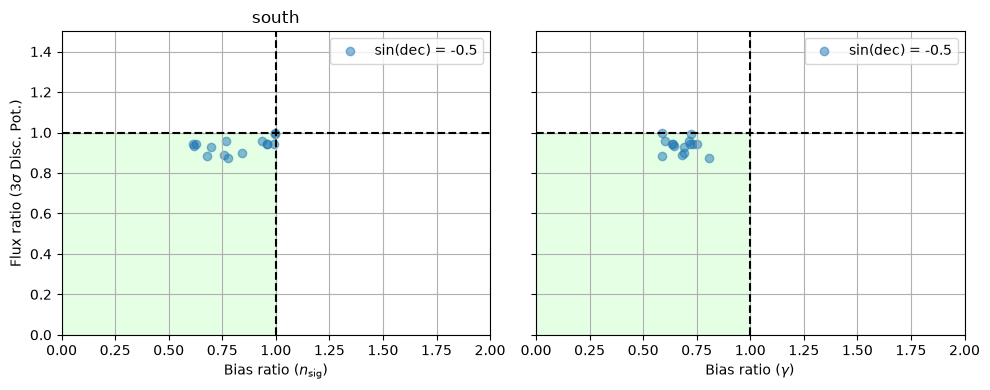

In [16]:
fig, axs = plt.subplots(1,2, figsize = (10, 4), sharey = True)
axs[0].fill_between([0,1], 0, 1, color = 'lime', alpha = 0.1, zorder = 0)
axs[0].axhline(1, color = 'black', linestyle = 'dashed')
axs[0].axvline(1, color = 'black', linestyle = 'dashed')
axs[0].set_xlim(0, 2)
axs[0].set_ylim(0, 1.5)
axs[0].scatter(north_best['ns_bias_ratio'], north_best['flux_ratio'], color = f'C{i}', label = f'sin(dec) = {sin_dec}', alpha = 0.5)
axs[0].legend()

axs[0].set_title(sky)
axs[0].grid()
axs[0].set_xlabel('Bias ratio ($n_{\\text{sig}}$)')
axs[0].set_ylabel('Flux ratio (3$\\sigma$ Disc. Pot.)')

axs[1].fill_between([0,1], 0, 1, color = 'lime', alpha = 0.1, zorder = 0)
axs[1].axhline(1, color = 'black', linestyle = 'dashed')
axs[1].axvline(1, color = 'black', linestyle = 'dashed')
axs[1].set_xlim(0, 2)
axs[1].set_ylim(0, 1.5)
axs[1].scatter(north_best['gamma_bias_ratio'], north_best['flux_ratio'], color = f'C{i}', label = f'sin(dec) = {sin_dec}', alpha = 0.5)
axs[1].legend()

axs[1].grid()
axs[1].set_xlabel('Bias ratio ($\\gamma$)')

fig.tight_layout()

In [17]:
ratio_dfs['north'].where(ratio_dfs['north']['run'] == 'E8_b26d8e_D14_fbbb47_S20_MC300').dropna()

,run,sin_dec,flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
280,E8_b26d8e_D14_fbbb47_S20_MC300,0.0,0.885585,0.950968,0.924539,2240.0,8.0,14.0,20.0


In [18]:
ratio_dfs['south'].where(ratio_dfs['south']['run'] == 'E15_D14_214963_S20_MC300').dropna()

,run,sin_dec,flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
70,E15_D14_214963_S20_MC300,-0.5,1.217516,0.84753,0.804052,4200.0,15.0,14.0,20.0


In [19]:
ratio_dfs['south'].where(ratio_dfs['south']['run'] == 'E25_86544b_D24_b2448a_S20_MC300').dropna()

,run,sin_dec,flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
198,E25_86544b_D24_b2448a_S20_MC300,-0.5,1.170947,0.922644,0.986102,12000.0,25.0,24.0,20.0


In [20]:
ratio_dfs['south'].where(ratio_dfs['south']['run'] == 'E5_D24_b2448a_S50_MC300').dropna()


,run,sin_dec,flux_ratio,ns_bias_ratio,gamma_bias_ratio,n_bins,n_bins_energy,n_bins_dec,n_bins_sigma
39,E5_D24_b2448a_S50_MC300,-0.5,1.259262,0.653963,0.95576,6000.0,5.0,24.0,50.0


### Correlation of number of bins to Bias

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3469577/228511171.py:7: SyntaxWarning: invalid escape sequence '\g'
  plt.scatter(ratio_dfs[sky]['n_bins'], ratio_dfs[sky]['gamma_bias_ratio'], alpha = 0.5, label = 'Spectral index $\gamma$')


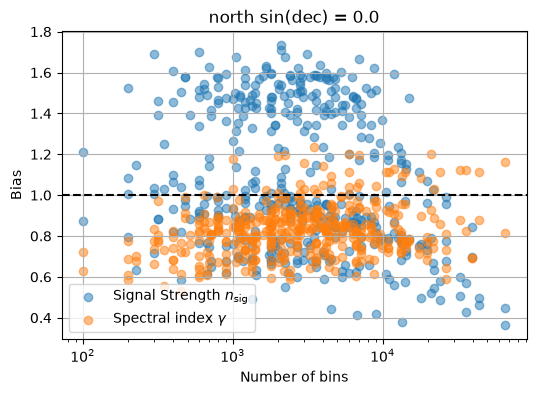

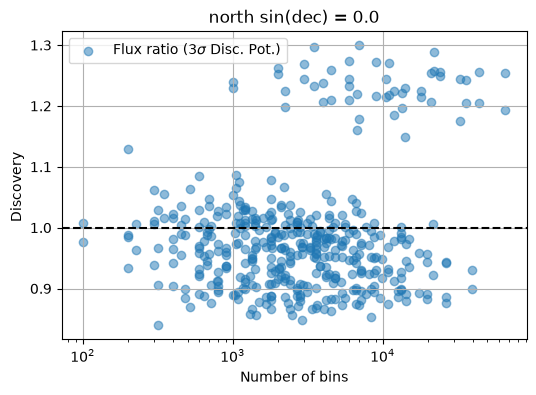

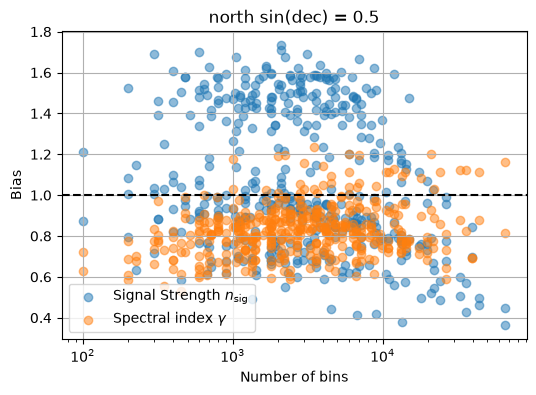

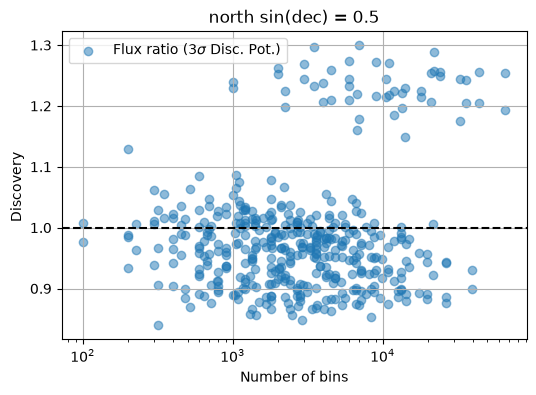

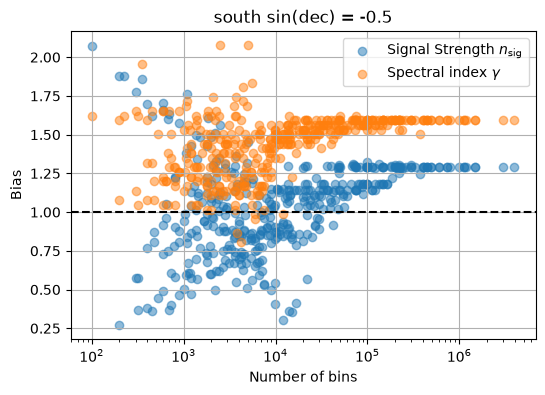

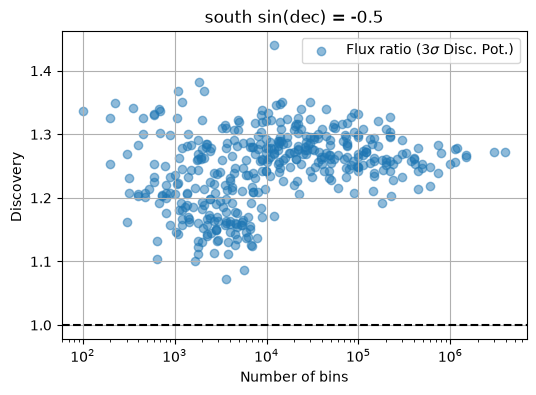

In [21]:
for sky in ['north', 'south']:
    for sin_dec in sin_decs[sky]:
        plt.figure(figsize= (6, 4))
        plt.grid()
        plt.title(sky +' sin(dec) = ' + str(sin_dec))
        plt.scatter(ratio_dfs[sky]['n_bins'],ratio_dfs[sky]['ns_bias_ratio'], alpha = 0.5, label = 'Signal Strength $n_{\\text{sig}}$')
        plt.scatter(ratio_dfs[sky]['n_bins'], ratio_dfs[sky]['gamma_bias_ratio'], alpha = 0.5, label = 'Spectral index $\gamma$')
        plt.xlabel('Number of bins')
        plt.ylabel('Bias')
        plt.axhline(1, linestyle = 'dashed', color = 'black')
        plt.xscale('log')
        plt.legend()
        
        plt.figure(figsize= (6, 4))
        plt.grid()
        plt.title(sky +' sin(dec) = '+ str(sin_dec))
        plt.scatter(ratio_dfs[sky]['n_bins'],ratio_dfs[sky]['flux_ratio'], alpha = 0.5, label = 'Flux ratio (3$\\sigma$ Disc. Pot.)')
        plt.xlabel('Number of bins')
        plt.ylabel('Discovery ')
        plt.axhline(1, linestyle = 'dashed', color = 'black')
        plt.xscale('log')
        plt.legend()

Now also look into what seperates the clouds:

/tmp/ipykernel_3469577/1826828793.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


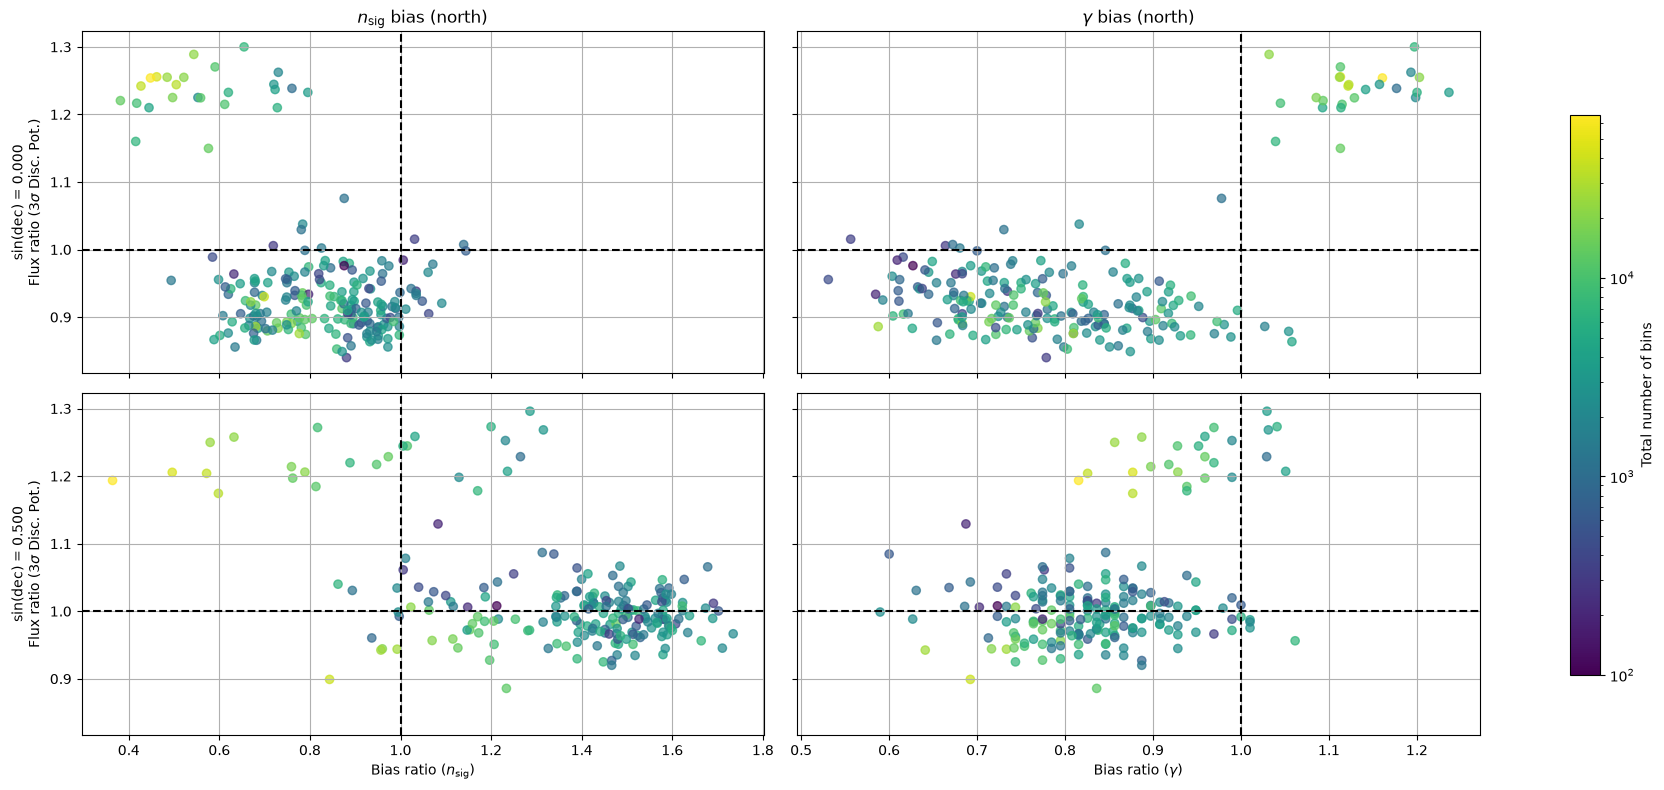

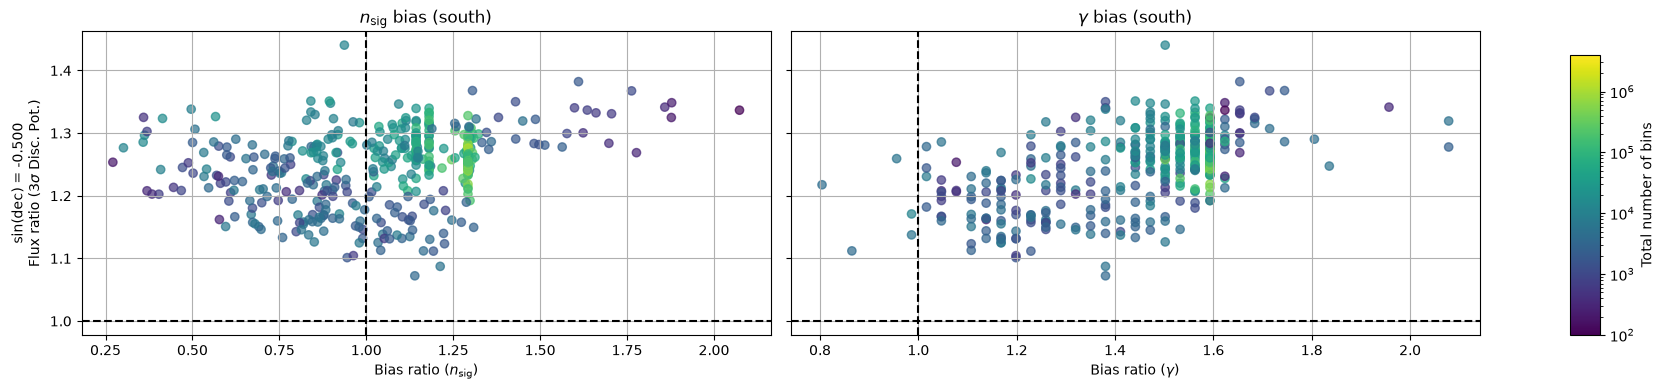

In [22]:
for sky in ['north', 'south']:

    fig, axs = plt.subplots(
        len(sin_decs[sky]),
        2,
        figsize=(15, 4 * len(sin_decs[sky]) ),
        sharex="col",
        sharey=True,
        squeeze=False,
    )

    # Use one common color scale across all declinations
    norm = mpl.colors.LogNorm(
        vmin=ratio_dfs[sky]["n_bins"].min(),
        vmax=ratio_dfs[sky]["n_bins"].max(),
    )

    cmap = "viridis"

    for i, sin_dec in enumerate(sin_decs[sky]):
        dec_df = ratio_dfs[sky].loc[
            ratio_dfs[sky]["sin_dec"] == sin_dec
        ]

        # n_sig bias
        axs[i, 0].scatter(
            dec_df["ns_bias_ratio"],
            dec_df["flux_ratio"],
            c=dec_df["n_bins"],
            cmap=cmap,
            norm=norm,
            alpha=0.7,
        )

        axs[i, 0].axhline(
            1,
            color="black",
            linestyle="dashed",
        )
        axs[i, 0].axvline(
            1,
            color="black",
            linestyle="dashed",
        )
        axs[i, 0].grid()
        axs[i, 0].set_ylabel(
            f"sin(dec) = {sin_dec:.3f}\n"
            "Flux ratio (3$\\sigma$ Disc. Pot.)"
        )

        # gamma bias
        axs[i, 1].scatter(
            dec_df["gamma_bias_ratio"],
            dec_df["flux_ratio"],
            c=dec_df["n_bins"],
            cmap=cmap,
            norm=norm,
            alpha=0.7,
        )

        axs[i, 1].axhline(
            1,
            color="black",
            linestyle="dashed",
        )
        axs[i, 1].axvline(
            1,
            color="black",
            linestyle="dashed",
        )
        axs[i, 1].grid()

    # Column labels
    axs[-1, 0].set_xlabel(
        "Bias ratio ($n_{\\mathrm{sig}}$)"
    )
    axs[-1, 1].set_xlabel(
        "Bias ratio ($\\gamma$)"
    )

    axs[0, 0].set_title("$n_{\\mathrm{sig}}$ bias " + f'({sky})')
    axs[0, 1].set_title("$\\gamma$ bias " + f'({sky})' )

    # Shared colorbar
    sm = mpl.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    sm.set_array([])

    fig.subplots_adjust(right=0.88)  # make room

    cax = fig.add_axes([1.05, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Total number of bins")

    fig.tight_layout()
    plt.show()

In [23]:

def plot_bias_by_binning(
    ratio_df,
    sin_decs,
    bin_column,
    colorbar_label,
    cmap="viridis",
    log_scale=True,
):
    fig, axs = plt.subplots(
        len(sin_decs),
        2,
        figsize=(15, 4 * len(sin_decs)),
        sharex="col",
        sharey=True,
        squeeze=False,
    )

    bin_values = ratio_df.loc[
        ratio_df[bin_column] > 0,
        bin_column,
    ]

    if log_scale:
        norm = mpl.colors.LogNorm(
            vmin=bin_values.min(),
            vmax=bin_values.max(),
        )
    else:
        norm = mpl.colors.Normalize(
            vmin=bin_values.min(),
            vmax=bin_values.max(),
        )

    for i, sin_dec in enumerate(sin_decs):
        dec_df = ratio_df.loc[
            ratio_df["sin_dec"] == sin_dec
        ]

        # n_sig bias
        axs[i, 0].scatter(
            dec_df["ns_bias_ratio"],
            dec_df["flux_ratio"],
            c=dec_df[bin_column],
            cmap=cmap,
            norm=norm,
            alpha=0.7,
        )

        # gamma bias
        axs[i, 1].scatter(
            dec_df["gamma_bias_ratio"],
            dec_df["flux_ratio"],
            c=dec_df[bin_column],
            cmap=cmap,
            norm=norm,
            alpha=0.7,
        )

        for ax in axs[i]:
            ax.axhline(
                1,
                color="black",
                linestyle="dashed",
            )
            ax.axvline(
                1,
                color="black",
                linestyle="dashed",
            )
            ax.grid()

        axs[i, 0].set_ylabel(
            f"sin(dec) = {sin_dec:.3f}\n"
            "Flux ratio (3$\\sigma$ Disc. Pot.)"
        )

    axs[-1, 0].set_xlabel(
        "Bias ratio ($n_{\\mathrm{sig}}$)"
    )
    axs[-1, 1].set_xlabel(
        "Bias ratio ($\\gamma$)"
    )

    axs[0, 0].set_title(
        f"$n_{{\\mathrm{{sig}}}}$ bias — {colorbar_label}"
    )
    axs[0, 1].set_title(
        f"$\\gamma$ bias — {colorbar_label}"
    )

    sm = mpl.cm.ScalarMappable(
        norm=norm,
        cmap=cmap,
    )
    sm.set_array([])

    # Reserve space on the right for the colorbar
    fig.subplots_adjust(
        right=0.88,
        hspace=0.25,
    )

    cax = fig.add_axes(
        [0.90, 0.15, 0.02, 0.70]
    )

    cbar = fig.colorbar(
        sm,
        cax=cax,
    )
    cbar.set_label(colorbar_label)

    plt.show()

    return fig, axs

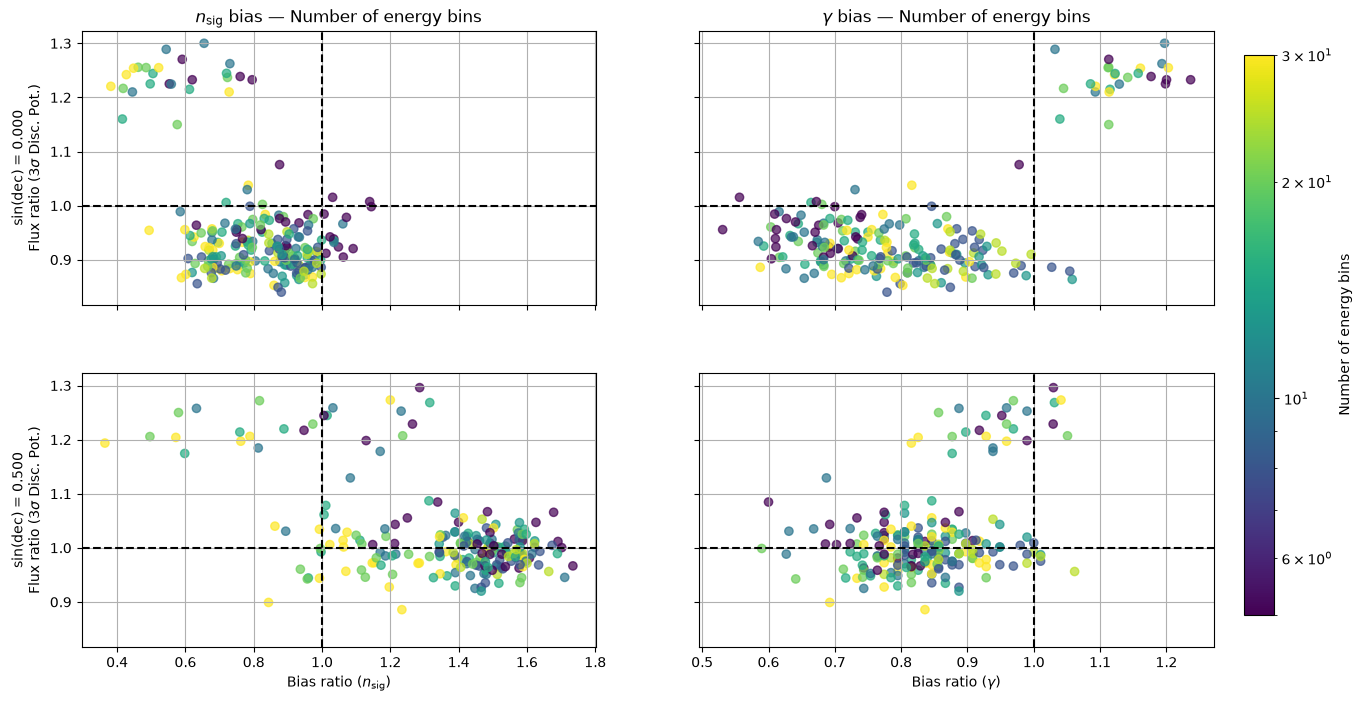

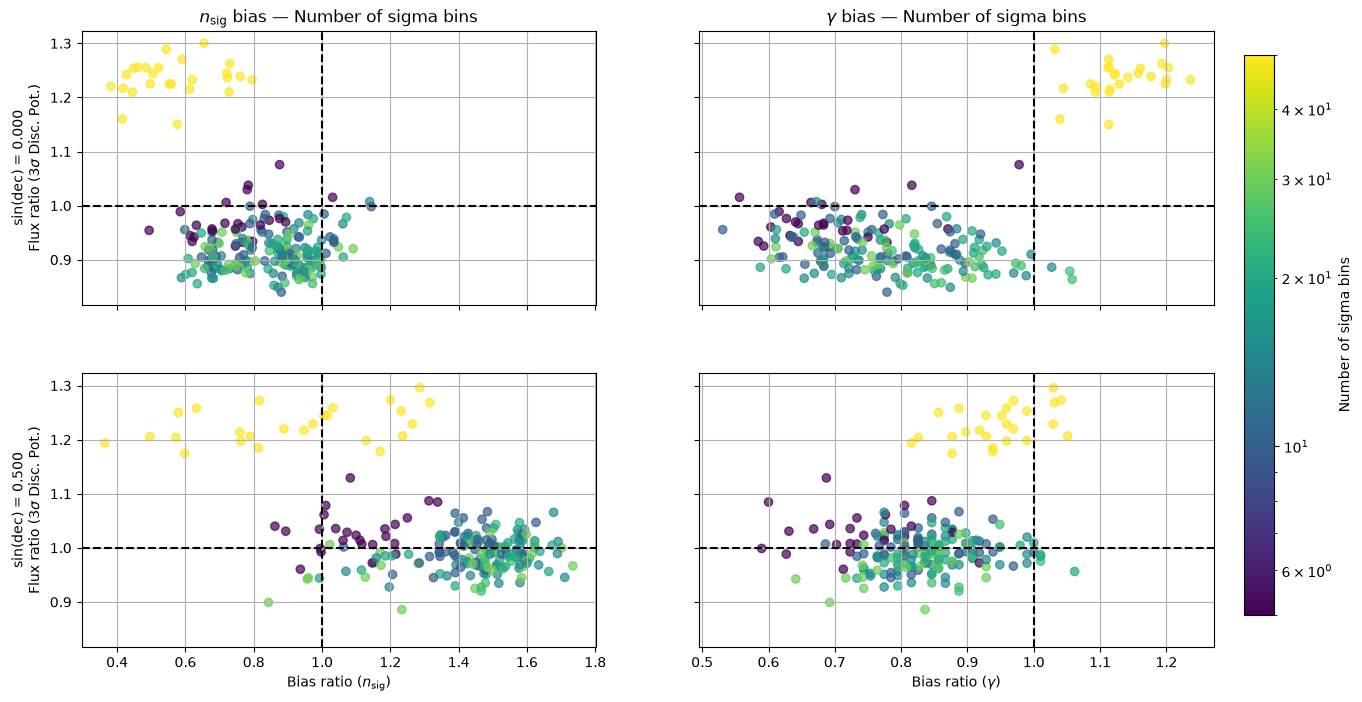

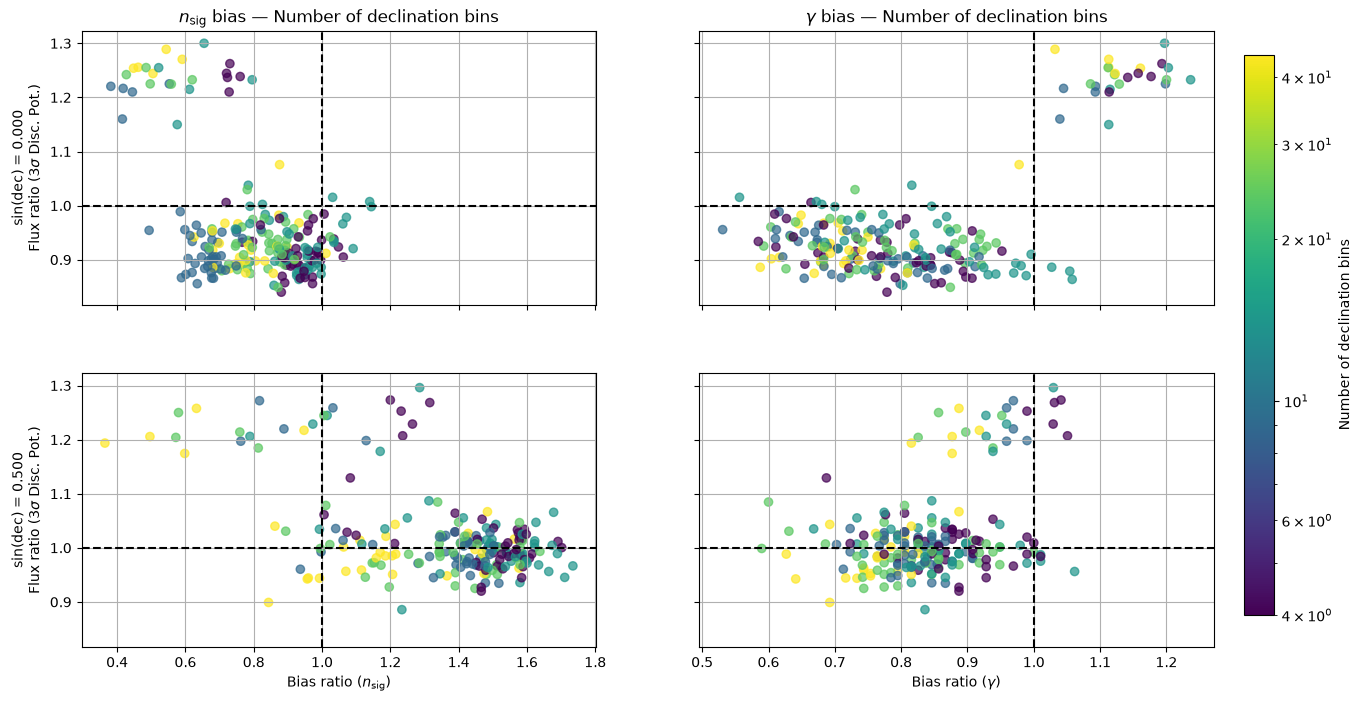

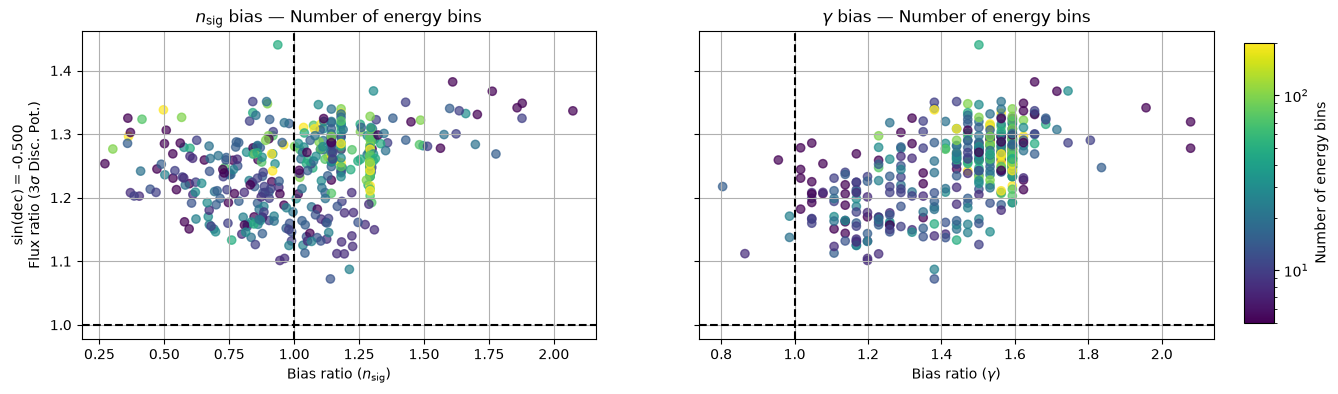

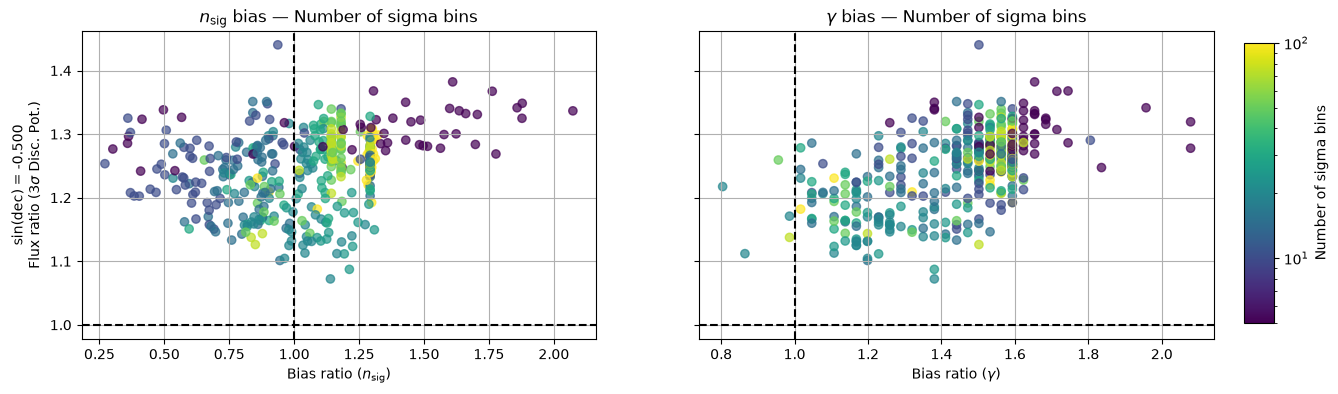

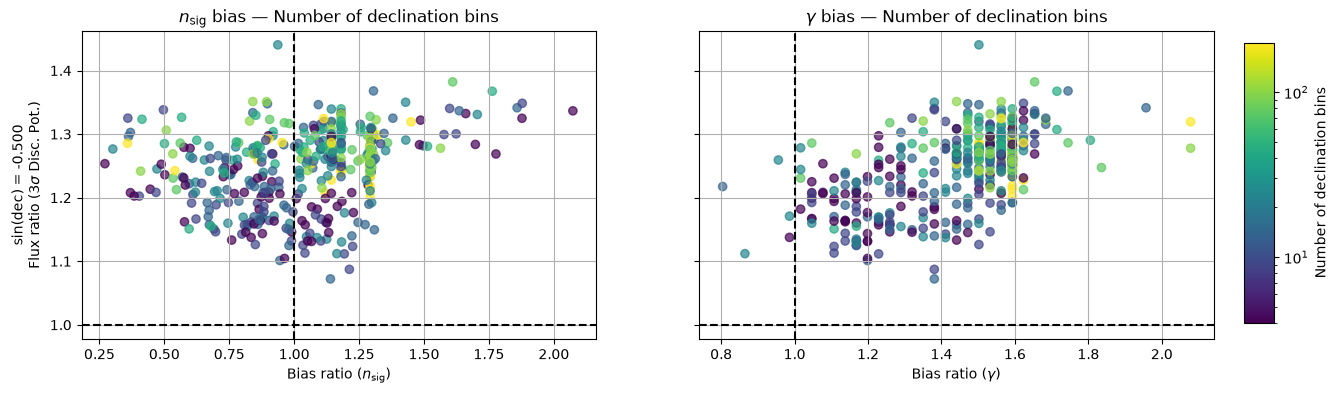

In [24]:
for sky in ['north', 'south']:
    fig_energy, axs_energy = plot_bias_by_binning(
        ratio_df=ratio_dfs[sky],
        sin_decs=sin_decs[sky],
        bin_column="n_bins_energy",
        colorbar_label="Number of energy bins",
    )

    fig_sigma, axs_sigma = plot_bias_by_binning(
        ratio_df=ratio_dfs[sky],
        sin_decs=sin_decs[sky],
        bin_column="n_bins_sigma",
        colorbar_label="Number of sigma bins",
    )

    fig_dec, axs_dec = plot_bias_by_binning(
        ratio_df=ratio_dfs[sky],
        sin_decs=sin_decs[sky],
        bin_column="n_bins_dec",
        colorbar_label="Number of declination bins",
    )

One thing seems noteworthy... In the n_sig bias plot considering number of sigma bins we can clearly see, that at sin(dec) = -0.5 more sigma bins improve disc potential but worsen the bias...
